In [1]:
import numpy as np
from scipy.io import loadmat
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.anova import AnovaRM
import os
from dotenv import load_dotenv; load_dotenv()
%cd {os.getenv('PROJECT_PATH')}

/home/dani/projects/neuroscience


In [2]:
# Read .mat files
data_ts = loadmat('data_processed/lsd/time_series_data.mat')
data_names = loadmat('data_processed/lsd/condition_names.mat')
parts = ['Thalamus','Visual_Cortex','Posterior_Cingulate_Cortex', 'Temporal_Gyrus']

data = {str(data_names['conditionNames'][0,i][0]): np.array([data_ts['pyDict'][0,i][part][0,0] for part in parts]).transpose(1,0,2) for i in range(3)}
print(data.keys())
n_subs, n_rois, n_time = data['LSD'].shape  # (number of subjects, number of ROIs, number of time points)

dict_keys(['Placebo', 'LSD', 'LSD+Ketanserin'])


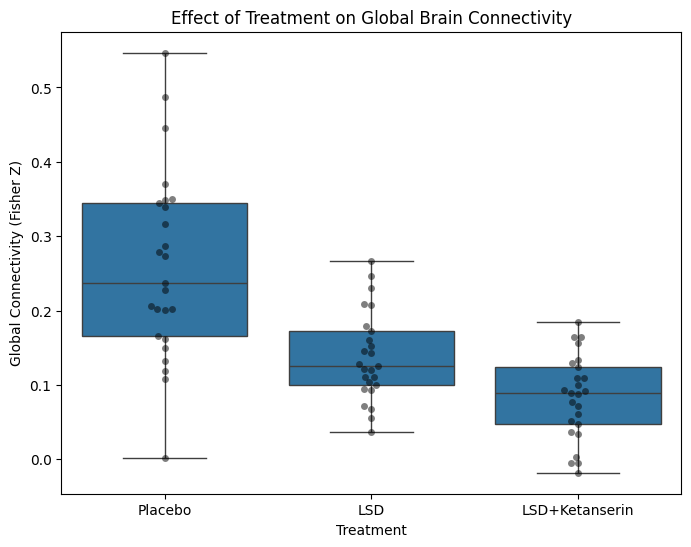

In [3]:

def compute_fc(time_series_data):
    """
    Input: (n_subs, n_rois, n_time)
    Output: (n_subs, n_rois, n_rois) - Fisher Z transformed matrices
    """
    n_s, n_r, n_t = time_series_data.shape
    fc_matrices = []
    
    for sub in range(n_s):
        # Transpose to (Time, ROIs) for corrcoef
        ts = time_series_data[sub, :, :]
        corr = np.corrcoef(ts)
        
        # Fisher Z transform (avoid inf at r=1 by clipping)
        corr = np.clip(corr, -0.999, 0.999)
        z_corr = np.arctanh(corr)
        fc_matrices.append(z_corr)
        
    return np.array(fc_matrices)

# 1. Compute Connectivity
fc_placebo = compute_fc(data['Placebo'])
fc_lsd = compute_fc(data['LSD'])
fc_ket = compute_fc(data['LSD+Ketanserin'])

# 2. Extract Mean Global Connectivity (upper triangle only)
# We mask the diagonal since it is always infinite/1
triu_indices = np.triu_indices(n_rois, k=1)

df_fc = pd.DataFrame({
    'Placebo': [m[triu_indices].mean() for m in fc_placebo],
    'LSD': [m[triu_indices].mean() for m in fc_lsd],
    'LSD+Ketanserin': [m[triu_indices].mean() for m in fc_ket]
})

# Reshape for plotting
df_long = df_fc.melt(var_name='Treatment', value_name='Global Connectivity (Fisher Z)')

# 3. Visualize
plt.figure(figsize=(8, 6))
sns.boxplot(x='Treatment', y='Global Connectivity (Fisher Z)', data=df_long)
sns.swarmplot(x='Treatment', y='Global Connectivity (Fisher Z)', data=df_long, color='black', alpha=0.5)
plt.title("Effect of Treatment on Global Brain Connectivity")
plt.show()

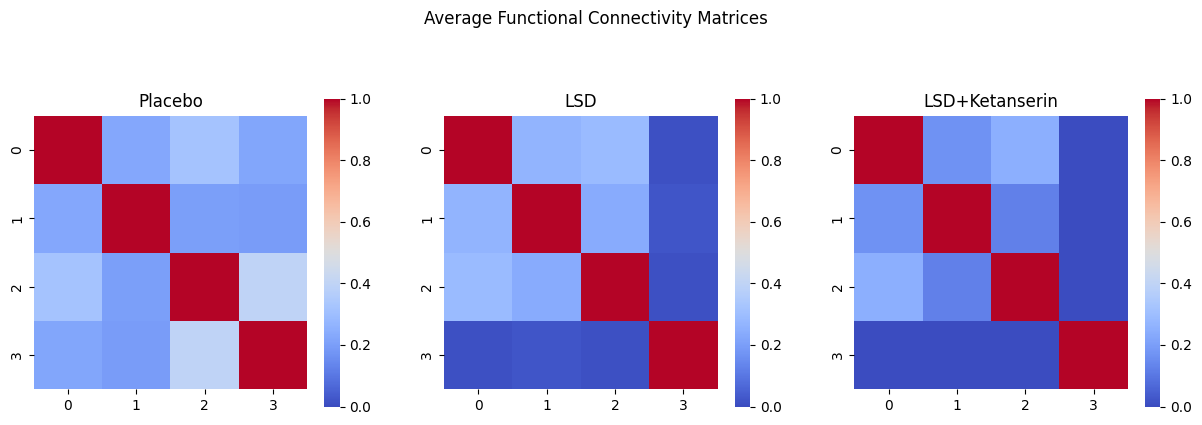

In [4]:
# plot 3 matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ['Placebo', 'LSD', 'LSD+Ketanserin']
for ax, fc_matrix, title in zip(axes, [fc_placebo.mean(axis=0), fc_lsd.mean(axis=0), fc_ket.mean(axis=0)], titles):
    sns.heatmap(fc_matrix, ax=ax, vmin=0, vmax=1, cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
    ax.set_title(title)
plt.suptitle("Average Functional Connectivity Matrices")
plt.show()

In [5]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# 1. Prepare Dataframe for Statsmodels
# We need columns: SubjectID, Treatment, Value
records = []
for treatment, matrices in zip(['Placebo', 'LSD', 'LSD+Ketanserin'], [fc_placebo, fc_lsd, fc_ket]):
    for sub_idx, matrix in enumerate(matrices):
        # Taking mean connectivity as the metric
        val = matrix[triu_indices].mean()
        records.append({'Subject': f'S{sub_idx}', 'Treatment': treatment, 'Connectivity': val})

df_stats = pd.DataFrame(records)
df_stats['Treatment'] = pd.Categorical(
    df_stats['Treatment'], 
    categories=['Placebo', 'LSD', 'LSD+Ketanserin'], 
    ordered=False
)

# 2. Now you can use a simpler formula without C()
md = smf.mixedlm("Connectivity ~ Treatment", df_stats, groups=df_stats["Subject"])
mdf = md.fit()
print(mdf.summary())

                Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     Connectivity
No. Observations:     75          Method:                 REML        
No. Groups:           25          Scale:                  0.0050      
Min. group size:      3           Log-Likelihood:         72.6041     
Max. group size:      3           Converged:              Yes         
Mean group size:      3.0                                             
----------------------------------------------------------------------
                            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------
Intercept                    0.260    0.017 14.920 0.000  0.226  0.294
Treatment[T.LSD]            -0.122    0.020 -6.133 0.000 -0.161 -0.083
Treatment[T.LSD+Ketanserin] -0.176    0.020 -8.866 0.000 -0.215 -0.137
Group Var                    0.003    0.022                           



/home/dani/projects/neuroscience/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [6]:
def compute_power_spectrum(data_dict, fs=1.0):
    """
    Applies FFT to time series to get Power Spectral Density (PSD).
    Returns a DataFrame suited for statistical modeling.
    """
    records = []
    
    for trt, matrix in data_dict.items():
        n_sub, n_rois, n_time = matrix.shape
        
        for s in range(n_sub):
            for r in range(n_rois):
                time_series = matrix[s, r, :]
                
                # Perform FFT
                freqs = np.fft.rfftfreq(n_time, d=1/fs)
                fft_vals = np.fft.rfft(time_series)
                power_spectrum = np.abs(fft_vals)**2
                
                # Feature Extraction: Average Power (or specific band power)
                # Here we take mean power as a summary statistic
                mean_power = np.mean(power_spectrum)
                
                records.append({
                    'Subject': s,
                    'Treatment': trt,
                    'ROI': f'ROI_{r}',
                    'Mean_Power': mean_power
                })
                
    return pd.DataFrame(records)

# ==========================================
# 3. Statistical Models
# ==========================================

def model_1_repeated_measures_anova(df, roi_of_interest='ROI_0'):
    """
    Model 1: One-way Repeated Measures ANOVA for a specific ROI.
    Tests if there is a significant difference between treatments within subjects.
    """
    print(f"\n--- Model 1: Repeated Measures ANOVA for {roi_of_interest} ---")
    
    # Filter for specific ROI
    roi_data = df[df['ROI'] == roi_of_interest]
    
    # Fit ANOVA
    aov = AnovaRM(
        data=roi_data, 
        depvar='Mean_Power', 
        subject='Subject', 
        within=['Treatment']
    )
    res = aov.fit()
    print(res)

def model_2_linear_mixed_effects(df):
    """
    Model 2: Linear Mixed Effects Model (LME).
    Allows modeling of random intercepts for subjects and ROI interactions.
    Equation: Power ~ Treatment + ROI + Treatment:ROI + (1|Subject)
    """
    print(f"\n--- Model 2: Linear Mixed Effects Model (LME) ---")
    
    # Define model: Fixed effects for Treatment and ROI, Random intercept for Subject
    # We use Treatment * ROI to see if drug effects differ by brain region
    md = smf.mixedlm("Mean_Power ~ Treatment * ROI", df, groups=df["Subject"])
    mdf = md.fit()
    
    print(mdf.summary())
    
    # Extract specific contrast (e.g., LSD vs Placebo)
    print("\nLSD Coefficient (vs Placebo baseline):")
    print(mdf.params[mdf.params.index.str.contains('LSD')])

In [7]:
# 2. FFT Processing
df_features = compute_power_spectrum(data, fs=0.5) # Assuming TR=2s -> fs=0.5Hz

# 3. Run Statistics
model_1_repeated_measures_anova(df_features, roi_of_interest='ROI_0')
model_1_repeated_measures_anova(df_features, roi_of_interest='ROI_1')
model_1_repeated_measures_anova(df_features, roi_of_interest='ROI_2')
model_1_repeated_measures_anova(df_features, roi_of_interest='ROI_3')


--- Model 1: Repeated Measures ANOVA for ROI_0 ---
                 Anova
          F Value Num DF  Den DF Pr > F
---------------------------------------
Treatment  3.8043 2.0000 48.0000 0.0293


--- Model 1: Repeated Measures ANOVA for ROI_1 ---
                 Anova
          F Value Num DF  Den DF Pr > F
---------------------------------------
Treatment  0.8608 2.0000 48.0000 0.4293


--- Model 1: Repeated Measures ANOVA for ROI_2 ---
                 Anova
          F Value Num DF  Den DF Pr > F
---------------------------------------
Treatment  1.5160 2.0000 48.0000 0.2299


--- Model 1: Repeated Measures ANOVA for ROI_3 ---
                 Anova
          F Value Num DF  Den DF Pr > F
---------------------------------------
Treatment -1.2884 2.0000 48.0000 1.0000




--- Model 2: Linear Mixed Effects Model (LME) ---


                         Mixed Linear Model Regression Results
Model:                       MixedLM           Dependent Variable:           Mean_Power
No. Observations:            300               Method:                       REML      
No. Groups:                  25                Scale:                        3026.4500 
Min. group size:             12                Log-Likelihood:               -1602.5733
Max. group size:             12                Converged:                    Yes       
Mean group size:             12.0                                                      
---------------------------------------------------------------------------------------
                                          Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
---------------------------------------------------------------------------------------
Intercept                                  30.795   12.896  2.388 0.017   5.520  56.071
Treatment[T.LSD+Ketanserin]                 4.417   15.56

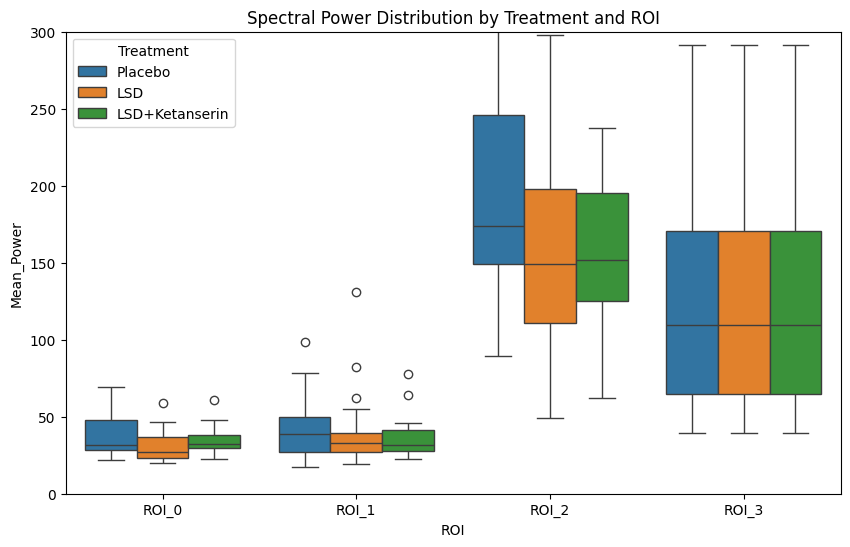

In [8]:
model_2_linear_mixed_effects(df_features)

# Optional: Visualization
plt.figure(figsize=(10, 6))
import seaborn as sns
sns.boxplot(x='ROI', y='Mean_Power', hue='Treatment', data=df_features)
plt.ylim(0,300)
plt.title('Spectral Power Distribution by Treatment and ROI')
plt.show()

The KS statistic is defined as:
$$D_{KS} = \sup_x |F_1(x) - F_2(x)|$$
Where $F(x)$ is the empirical step function. The derivative of a step function is 0. If you try to optimize this, your gradient will be zero, and the parameter $G$ will never update.The 1-Wasserstein Distance (for 1D distributions) corresponds to the area between the two CDFs, or equivalently, the mean absolute error between the sorted vectors:
$$W_1(u, v) = \int_0^1 |F_1^{-1}(z) - F_2^{-1}(z)| dz$$